In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
df = pd.read_csv("earthquake_cleaned (3).csv")

In [ ]:
df.head()

,id,time,updated,latitude,longitude,depth_km,mag,magType,place,status,...,rms,gap,type,country,year,month,day,day_of_week,depth_category,strength_category
0,us6000ddi8,2021-01-31 23:20:49.923,2021-04-16 19:02:44.040,-31.7493,-68.9337,17.27,4.7,mwr,"29 km SW of Villa Basilio Nievas, Argentina",reviewed,...,0.82,42.0,earthquake,Argentina,2021,1,31,Sunday,Shallow,Moderate
1,us6000dev6,2021-01-31 23:08:17.161,2021-04-16 19:03:47.040,-15.4902,-177.2052,426.71,4.1,mb,Fiji region,reviewed,...,0.29,64.0,earthquake,Fiji,2021,1,31,Sunday,Deep,Moderate
2,us6000dev5,2021-01-31 22:54:19.760,2021-04-16 19:03:47.040,19.7529,121.3159,46.73,4.7,mb,"103 km SW of Basco, Philippines",reviewed,...,0.69,106.0,earthquake,Philippines,2021,1,31,Sunday,Shallow,Moderate
3,us6000ddhs,2021-01-31 22:06:00.832,2021-04-16 19:02:43.040,28.1524,57.2570,10.00,4.9,mb,"114 km N of M?n?b, Iran",reviewed,...,0.61,71.0,earthquake,Iran,2021,1,31,Sunday,Shallow,Moderate
4,us6000dev4,2021-01-31 21:51:14.016,2021-04-16 19:03:46.040,71.3212,-3.7578,10.00,4.0,mb,"184 km ENE of Olonkinbyen, Svalbard and Jan Mayen",reviewed,...,0.50,65.0,earthquake,Svalbard and Jan Mayen,2021,1,31,Sunday,Shallow,Moderate


In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (111763, 33)


In [ ]:
df.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'alert', 'felt', 'cdi', 'mmi',
       'sig', 'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms',
       'gap', 'type', 'country', 'year', 'month', 'day', 'day_of_week',
       'depth_category', 'strength_category'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111763 entries, 0 to 111762
Data columns (total 33 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 111763 non-null  object 
 1   time               111763 non-null  object 
 2   updated            111763 non-null  object 
 3   latitude           111763 non-null  float64
 4   longitude          111763 non-null  float64
 5   depth_km           111763 non-null  float64
 6   mag                111763 non-null  float64
 7   magType            111763 non-null  object 
 8   place              111763 non-null  object 
 9   status             111763 non-null  object 
 10  tsunami            111763 non-null  int64  
 11  alert              4570 non-null    object 
 12  felt               111763 non-null  float64
 13  cdi                111763 non-null  float64
 14  mmi                111763 non-null  float64
 15  sig                111763 non-null  int64  
 16  ne

In [ ]:
df.describe()

,latitude,longitude,depth_km,mag,tsunami,felt,cdi,mmi,sig,nst,dmin,rms,gap,year,month,day
count,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000,111763.000000
mean,12.090826,7.228219,71.913317,4.256906,0.005896,17.725428,3.119578,3.402284,287.582849,42.080116,3.136922,0.656403,122.109427,2023.198644,6.272031,15.451106
std,32.048074,129.009528,123.402731,0.609466,0.076562,675.199834,0.592588,0.473201,91.350468,34.700237,4.369868,0.258021,62.111687,1.580929,3.494420,8.884857
min,-84.493200,-179.999700,-3.740000,3.000000,0.000000,0.000000,0.000000,0.000000,138.000000,0.000000,0.000000,0.000000,8.000000,2021.000000,1.000000,1.000000
25%,-14.738750,-114.225900,10.000000,4.000000,0.000000,3.000000,3.100000,3.414000,247.000000,24.000000,0.860000,0.490000,76.000000,2022.000000,3.000000,8.000000
50%,15.004100,23.622700,21.421000,4.300000,0.000000,3.000000,3.100000,3.414000,284.000000,32.000000,1.811000,0.650000,113.000000,2023.000000,6.000000,15.000000
75%,39.052600,130.495200,71.100000,4.600000,0.000000,3.000000,3.100000,3.414000,326.000000,46.000000,3.614000,0.820000,154.000000,2025.000000,9.000000,23.000000
max,87.375200,179.999400,683.578000,8.800000,1.000000,184659.000000,9.100000,9.953000,2910.000000,619.000000,62.558000,3.400000,358.180000,2026.000000,12.000000,31.000000


In [ ]:
df.isnull().sum()

,0
id,0
time,0
updated,0
latitude,0
longitude,0
depth_km,0
mag,0
magType,0
place,0
status,0


In [ ]:
top_countries = df['country'].value_counts().head(10)

top_countries

,count
country,
Alaska,13617
Indonesia,8625
Russia,6125
Japan,4949
Philippines,4638
Papua New Guinea,3590
Puerto Rico,3330
Tonga,3125
South Sandwich Islands,3104


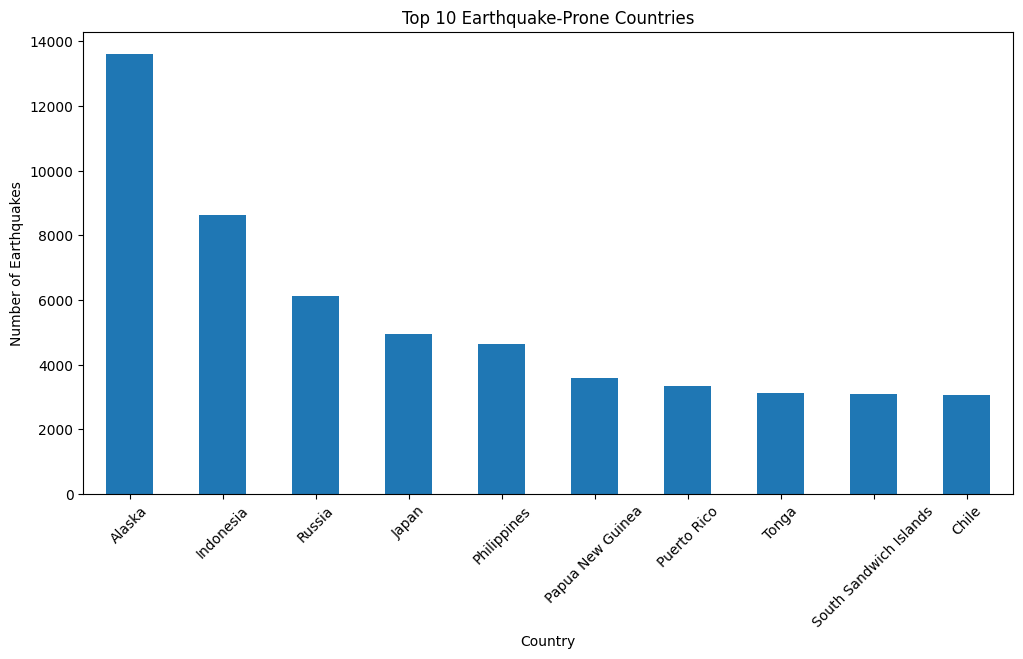

In [ ]:
plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Earthquake-Prone Countries")
plt.xlabel("Country")
plt.ylabel("Number of Earthquakes")

plt.xticks(rotation=45)

plt.show()
#Countries located near tectonic plate boundaries recorded the highest number of earthquakes.

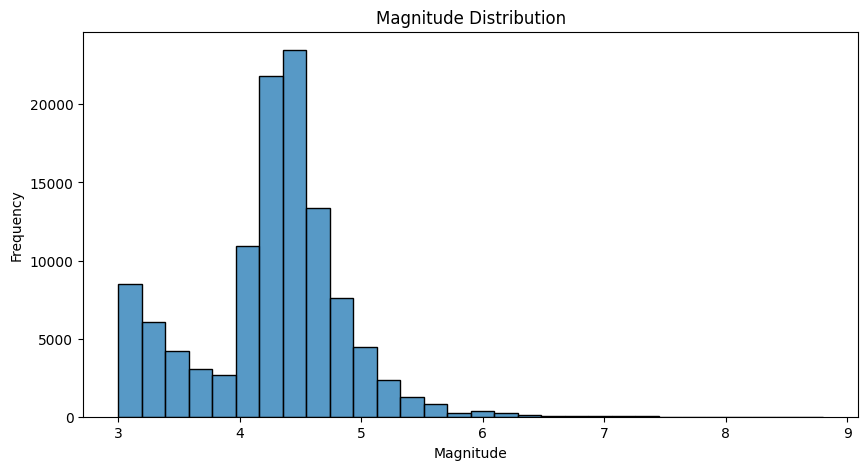

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['mag'], bins=30)

plt.title("Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")

plt.show()
#Most earthquakes fall within low-to-moderate magnitude ranges.

In [ ]:
print("Average Depth:", df['depth_km'].mean())

Average Depth: 71.91331651423287


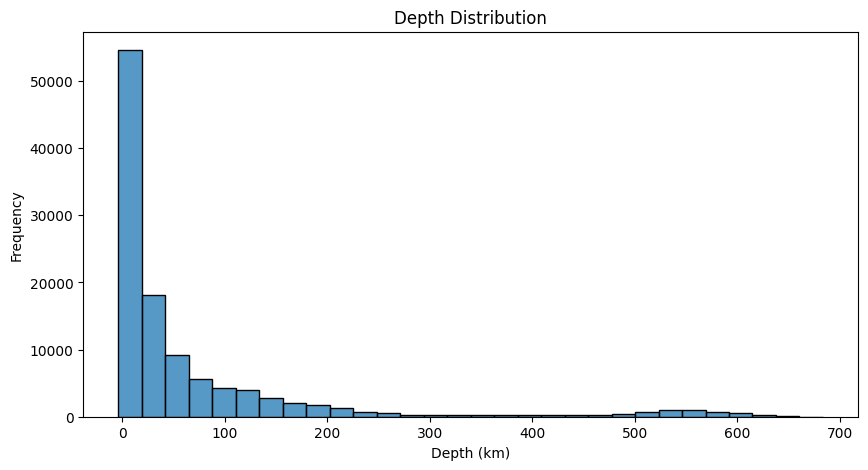

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['depth_km'], bins=30)

plt.title("Depth Distribution")
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
depth_counts = df['depth_category'].value_counts()

depth_counts

,count
depth_category,
Shallow,76152
Deep,35611


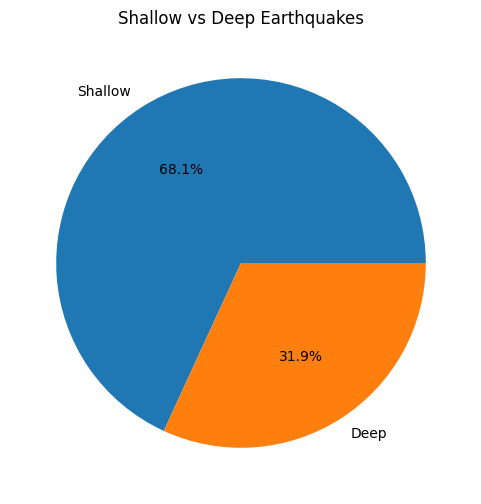

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    depth_counts,
    labels=depth_counts.index,
    autopct='%1.1f%%'
)

plt.title("Shallow vs Deep Earthquakes")

plt.show()
#Most earthquakes were shallow-focus events.

In [ ]:
yearly_counts = df['year'].value_counts().sort_index()

yearly_counts

,count
year,
2021,21926
2022,20208
2023,20830
2024,18659
2025,22818
2026,7322


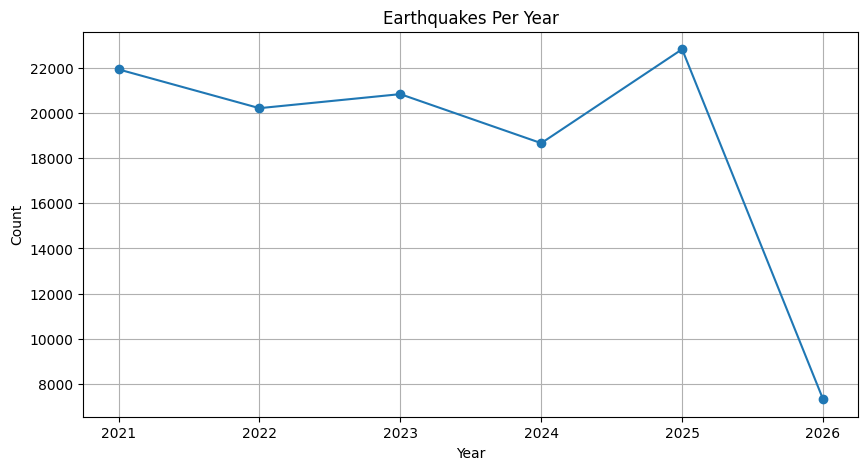

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_counts.index,
    yearly_counts.values,
    marker='o'
)

plt.title("Earthquakes Per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.grid()

plt.show()
#Earthquake frequency varied across years with noticeable fluctuations.

In [ ]:
monthly_counts = df['month'].value_counts().sort_index()

monthly_counts

,count
month,
1,10545
2,10041
3,10864
4,10183
5,8637
6,7721
7,9825
8,9857
9,8316


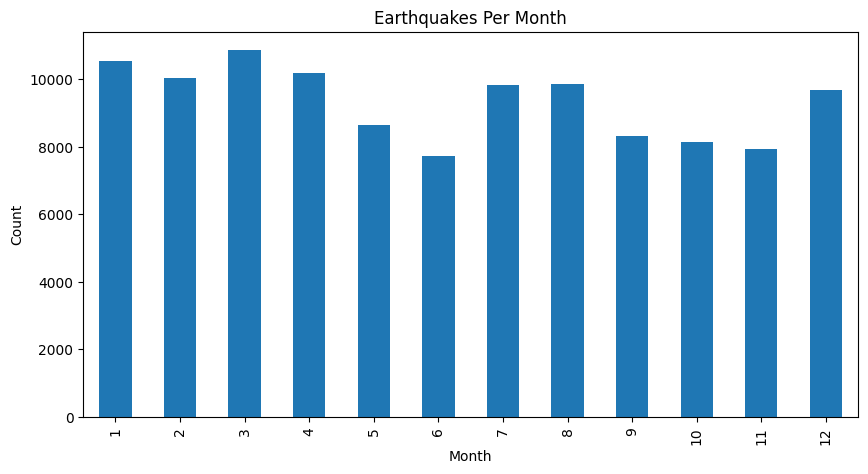

In [ ]:
plt.figure(figsize=(10,5))

monthly_counts.plot(kind='bar')

plt.title("Earthquakes Per Month")
plt.xlabel("Month")
plt.ylabel("Count")

plt.show()

In [ ]:
alert_counts = df['alert'].value_counts()

alert_counts

,count
alert,
green,4396
yellow,128
red,24
orange,22


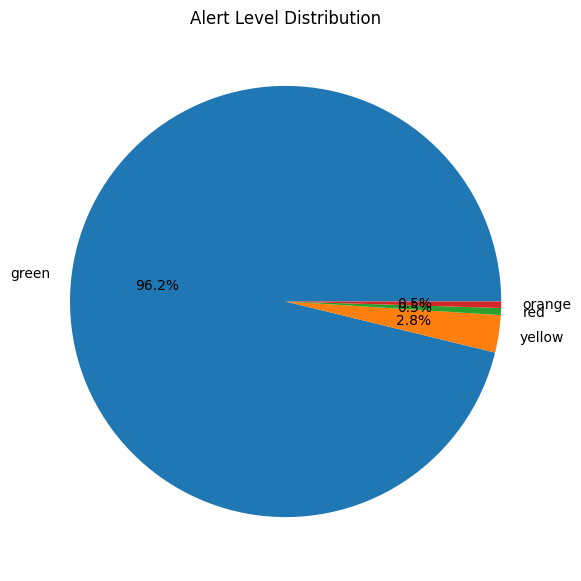

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    alert_counts,
    labels=alert_counts.index,
    autopct='%1.1f%%'
)

plt.title("Alert Level Distribution")

plt.show()

In [ ]:
tsunami_counts = df['tsunami'].value_counts()

tsunami_counts

,count
tsunami,
0,111104
1,659


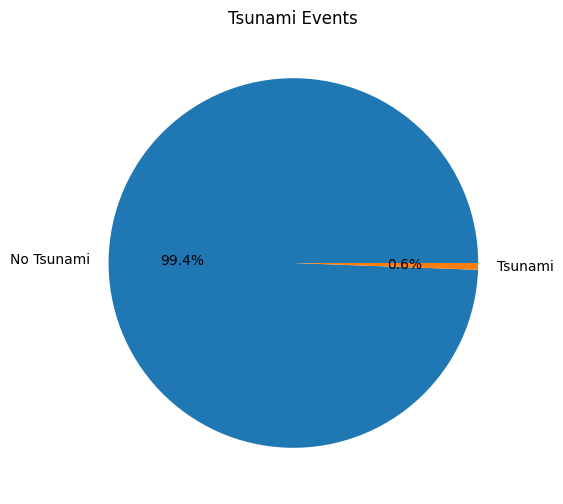

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    tsunami_counts,
    labels=['No Tsunami', 'Tsunami'],
    autopct='%1.1f%%'
)

plt.title("Tsunami Events")

plt.show()
#Only a small percentage of earthquakes triggered tsunami events.

In [ ]:
correlation = df[['mag','depth_km','felt']].corr()

correlation

,mag,depth_km,felt
mag,1.000000,0.051635,0.007487
depth_km,0.051635,1.000000,-0.010088
felt,0.007487,-0.010088,1.000000


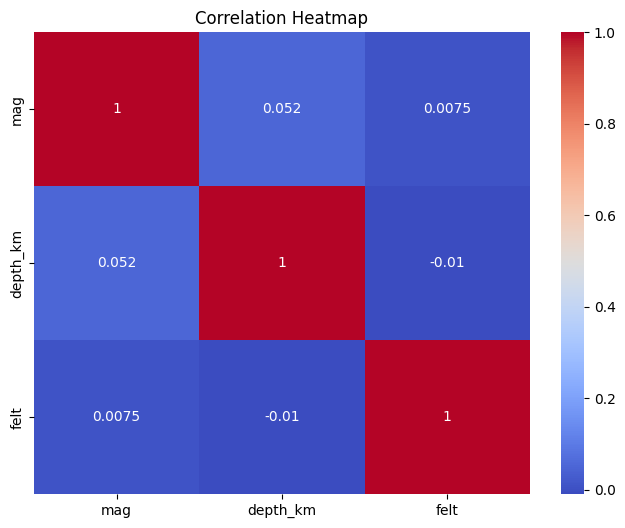

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

1. Most earthquakes were shallow-focus events.
2. Countries near tectonic boundaries experienced higher seismic activity.
3. Tsunami-triggering earthquakes generally had higher magnitudes.
4. The majority of events received no official alert classification.
5. Earthquake frequency fluctuated across years and months.